In [55]:
import pandas as pd 
import numpy as np

df = pd.read_csv ("flipkart_com-ecommerce_sample.csv")

print(f"Dataset successfully loaded!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset successfully loaded!
Total Rows: 20002
Total Columns: 15


In [56]:
#remove blank rows
df.dropna(subset=['retail_price','discounted_price'],inplace=True)

In [57]:
#new column
df['discount_amount'] = df['retail_price'] - df['discounted_price']   #new column

In [58]:
  #nc for dis %
df['discount_percentage'] = (df['discount_amount'] / df['retail_price']) * 100   

In [59]:
#clean
df['product_rating'] = df['product_rating'].replace('No rating available', np.nan)   

In [60]:
# text format to numeric format
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')

In [61]:
# Calculate the median rating and fill with it

median_rating = df['product_rating'].median()

df['product_rating'] = df['product_rating'].fillna(median_rating)

In [62]:
# Clean
df['primary_category'] = df['product_category_tree'].str.split('>>').str[0]

df['primary_category'] = df['primary_category'].str.replace('[', '', regex=False)
df['primary_category'] = df['primary_category'].str.replace('"', '', regex=False)
df['primary_category'] = df['primary_category'].str.strip()

In [63]:
# Count duplicate
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 0


In [64]:
#fix
df.drop_duplicates(inplace=True)
print(f"Rows remaining after removing duplicates: {df.shape[0]}")

Rows remaining after removing duplicates: 19922


In [65]:
# data type 
print("Data type of product_rating:", df['product_rating'].dtype)
print("Data type of overall_rating:", df['overall_rating'].dtype)
print("-" * 50)

# first 10 unique values
print("Unique values in product_rating (First 10):")
print(df['product_rating'].unique()[:10])

Data type of product_rating: float64
Data type of overall_rating: object
--------------------------------------------------
Unique values in product_rating (First 10):
[4.  5.  3.  3.6 3.5 4.4 1.  2.3 4.8 2.7]


In [66]:
# Replace
df['product_rating'] = df['product_rating'].replace('No rating available', np.nan)
df['overall_rating'] = df['overall_rating'].replace('No rating available', np.nan)

# 2. Convert to numeric float type
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['overall_rating'] = pd.to_numeric(df['overall_rating'], errors='coerce')

# 3. VERIFY
print("New data type for product_rating:", df['product_rating'].dtype)
print(f"Total blank rows now waiting to be filled: {df['product_rating'].isnull().sum()}")

New data type for product_rating: float64
Total blank rows now waiting to be filled: 0


In [67]:
# median
median_prod_rating = df['product_rating'].median()
median_over_rating = df['overall_rating'].median()

# 2. Fill median values
df['product_rating'] = df['product_rating'].fillna(median_prod_rating)
df['overall_rating'] = df['overall_rating'].fillna(median_over_rating)

# 3. VERIFY
print(f"Remaining blank rows in product_rating: {df['product_rating'].isnull().sum()}")
print(f"Remaining blank rows in overall_rating: {df['overall_rating'].isnull().sum()}")

Remaining blank rows in product_rating: 0
Remaining blank rows in overall_rating: 0


In [68]:
# text
print("Raw Category Tree Examples:")
print(df['product_category_tree'].head(5).to_string())

Raw Category Tree Examples:
0    ["Clothing >> Women's Clothing >> Lingerie, Sl...
1    ["Furniture >> Living Room Furniture >> Sofa B...
2    ["Footwear >> Women's Footwear >> Ballerinas >...
3    ["Clothing >> Women's Clothing >> Lingerie, Sl...
4    ["Pet Supplies >> Grooming >> Skin & Coat Care...


In [69]:
# clean
df['primary_category'] = df['product_category_tree'].str.split('>>').str[0]

df['primary_category'] = df['primary_category'].str.replace('[', '', regex=False)
df['primary_category'] = df['primary_category'].str.replace('"', '', regex=False)
df['primary_category'] = df['primary_category'].str.strip()

# 3. VERIFY
print("Clean Primary Categories (First 5 rows):")
print(df['primary_category'].head(5))

Clean Primary Categories (First 5 rows):
0        Clothing
1       Furniture
2        Footwear
3        Clothing
4    Pet Supplies
Name: primary_category, dtype: object


In [70]:
# Count 
missing_brands = df['brand'].isnull().sum()
print(f"Total rows missing a brand name: {missing_brands}")

Total rows missing a brand name: 5851


In [71]:
# Get the first word of every product name 
backup_brand = df['product_name'].str.split().str[0]

# Fill 
df['brand'] = df['brand'].fillna(backup_brand)

# 3. VERIFY
print(f"Remaining blank rows in the brand column: {df['brand'].isnull().sum()}")

Remaining blank rows in the brand column: 0


In [72]:
# Print the rows where the brand is still missing
print("The 2 rows with missing brands:")
print(df[df['brand'].isnull()][['product_name', 'brand']])

The 2 rows with missing brands:
Empty DataFrame
Columns: [product_name, brand]
Index: []


In [73]:
# missing brand fill with genric 
df['brand'] = df['brand'].fillna('Generic')

# VERIFY
print(f"Final missing brand count: {df['brand'].isnull().sum()}")

Final missing brand count: 0


In [74]:
# columns
print("Current columns in our dataset:")
print(df.columns.tolist())

Current columns in our dataset:
['uniq_id', 'crawl_timestamp', 'product_url', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'is_FK_Advantage_product', 'description', 'product_rating', 'overall_rating', 'brand', 'product_specifications', 'discount_amount', 'discount_percentage', 'primary_category']


In [75]:
#  C for dis value
df['discount_amount'] = df['retail_price'] - df['discounted_price']

# c for discount percentage
df['discount_percentage'] = (df['discount_amount'] / df['retail_price']) * 100

# 3. VERIFY
print("New business metrics successfully added:")
print(df[['retail_price', 'discounted_price', 'discount_amount', 'discount_percentage']].head(3))

New business metrics successfully added:
   retail_price  discounted_price  discount_amount  discount_percentage
0         999.0             379.0            620.0            62.062062
1       32157.0           22646.0           9511.0            29.576764
2         999.0             499.0            500.0            50.050050


In [76]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,discount_amount,discount_percentage,primary_category
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,4.0,4.0,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",620.0,62.062062,Clothing
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,4.0,4.0,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati...",9511.0,29.576764,Furniture
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,4.0,4.0,AW,"{""product_specification""=>[{""key""=>""Ideal For""...",500.0,50.050050,Footwear
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,4.0,4.0,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",432.0,61.802575,Clothing
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,4.0,4.0,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",10.0,4.545455,Pet Supplies


In [77]:
# EDA

In [78]:
#count
category_counts = df['primary_category'].value_counts().head(10)

print("Top 10 Categories by Product Volume:")
print(category_counts)

Top 10 Categories by Product Volume:
primary_category
Clothing                      6171
Jewellery                     3522
Footwear                      1225
Mobiles & Accessories         1097
Automotive                    1010
Home Decor & Festive Needs     927
Beauty and Personal Care       709
Home Furnishing                700
Kitchen & Dining               645
Computers                      573
Name: count, dtype: int64


In [79]:
# top 10 categories
top_10_categories = df['primary_category'].value_counts().head(10).index
df_top10 = df[df['primary_category'].isin(top_10_categories)]

# avg dis
avg_discounts = df_top10.groupby('primary_category')['discount_percentage'].mean().sort_values(ascending=False)

print("Average Discount Percentage by Top Categories:")
print(avg_discounts)

Average Discount Percentage by Top Categories:
primary_category
Automotive                    54.650991
Mobiles & Accessories         50.994470
Clothing                      45.070525
Kitchen & Dining              43.771695
Computers                     43.467316
Jewellery                     40.889934
Home Furnishing               37.218050
Home Decor & Festive Needs    36.649404
Footwear                      36.268531
Beauty and Personal Care      19.829674
Name: discount_percentage, dtype: float64


In [80]:
# avg retail price 
avg_retail = df_top10.groupby('primary_category')['retail_price'].mean().sort_values(ascending=False)

print("Average Original Retail Price by Top Categories:")
print(avg_retail)

Average Original Retail Price by Top Categories:
primary_category
Jewellery                     7662.524418
Computers                     3236.080279
Automotive                    2903.330693
Home Decor & Festive Needs    2770.839266
Home Furnishing               1941.932857
Mobiles & Accessories         1810.090246
Footwear                      1744.165714
Clothing                      1369.218441
Kitchen & Dining               914.720930
Beauty and Personal Care       848.575458
Name: retail_price, dtype: float64


In [81]:
# top 10 
top_brands = df['brand'].value_counts().head(10)

print("Top 10 Brands by Product Volume:")
print(top_brands)

Top 10 Brands by Product Volume:
brand
Allure Auto     468
Regular         308
Voylla          299
Slim            284
TheLostPuppy    229
Karatcraft      211
Black           169
White           157
DailyObjects    144
Speedwav        141
Name: count, dtype: int64


In [82]:
# top 10 brands
top_10_brands_list = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_10_brands_list)]

# avg top 10 brands
brand_prices = df_top_brands.groupby('brand')['retail_price'].mean().sort_values(ascending=False)

print("Average Original Retail Price for Top 10 Brands:")
print(brand_prices)

Average Original Retail Price for Top 10 Brands:
brand
Karatcraft      37077.777251
Allure Auto      4215.587607
TheLostPuppy     2120.397380
Slim             2053.841549
DailyObjects     1999.000000
Speedwav         1336.553191
Regular          1019.048701
Black            1013.207101
Voylla            820.307692
White             729.859873
Name: retail_price, dtype: float64


In [83]:
# avg discount
brand_discounts = df_top_brands.groupby('brand')['discount_percentage'].mean().sort_values(ascending=False)

print("Average Discount Percentage for Top 10 Brands:")
print(brand_discounts)

Average Discount Percentage for Top 10 Brands:
brand
TheLostPuppy    70.617094
Allure Auto     65.966460
White           62.025373
Black           61.301789
Regular         48.377776
Speedwav        47.533458
Slim            47.113010
Karatcraft      28.199355
Voylla          23.639215
DailyObjects    15.707854
Name: discount_percentage, dtype: float64


In [84]:
# ratings
rating_counts = df['product_rating'].value_counts()

print("Distribution of Product Ratings:")
print(rating_counts)

Distribution of Product Ratings:
product_rating
4.0    18328
5.0      618
1.0      169
3.0      168
2.0       79
4.5       67
3.7       51
4.2       47
3.5       44
4.3       44
3.6       25
4.1       24
4.7       24
2.5       22
3.8       22
4.8       21
3.2       20
3.3       17
4.4       16
3.9       15
3.4       13
2.3       12
2.8       11
2.7       10
4.6        9
2.2        8
3.1        7
2.4        5
2.9        5
1.5        4
4.9        4
1.3        4
1.7        4
2.6        3
1.8        2
Name: count, dtype: int64


In [85]:
# correlation 
correlation = df['discount_percentage'].corr(df['product_rating'])

print(f"Correlation between Discounts and Ratings: {correlation:.4f}")

Correlation between Discounts and Ratings: 0.0051


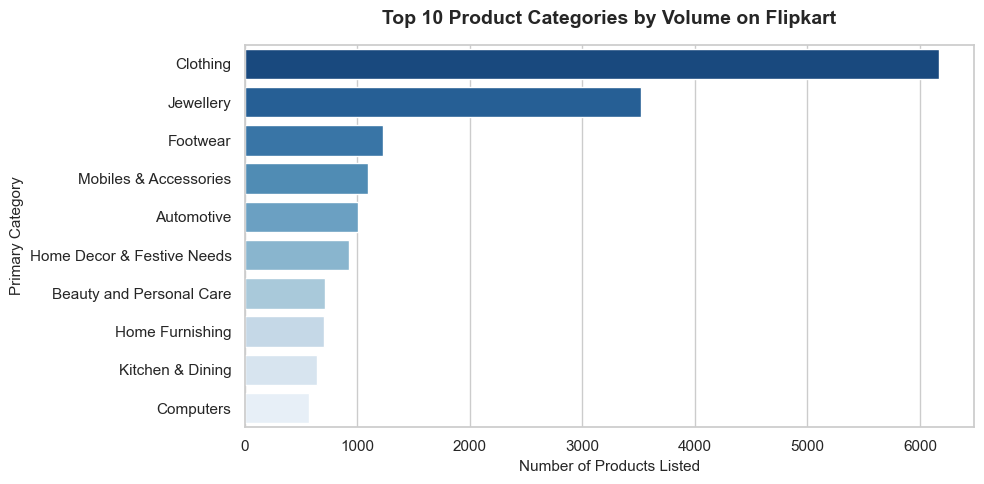

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# top 10 
top_10_categories = df['primary_category'].value_counts().head(10)

# bar chart (y=categories, x=counts)
sns.barplot(
    x=top_10_categories.values, 
    y=top_10_categories.index, 
    hue=top_10_categories.index,
    legend=False,
    palette="Blues_r"  #dark blue to light
)

plt.title("Top 10 Product Categories by Volume on Flipkart", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Products Listed", fontsize=11)
plt.ylabel("Primary Category", fontsize=11)

plt.tight_layout()
plt.show()

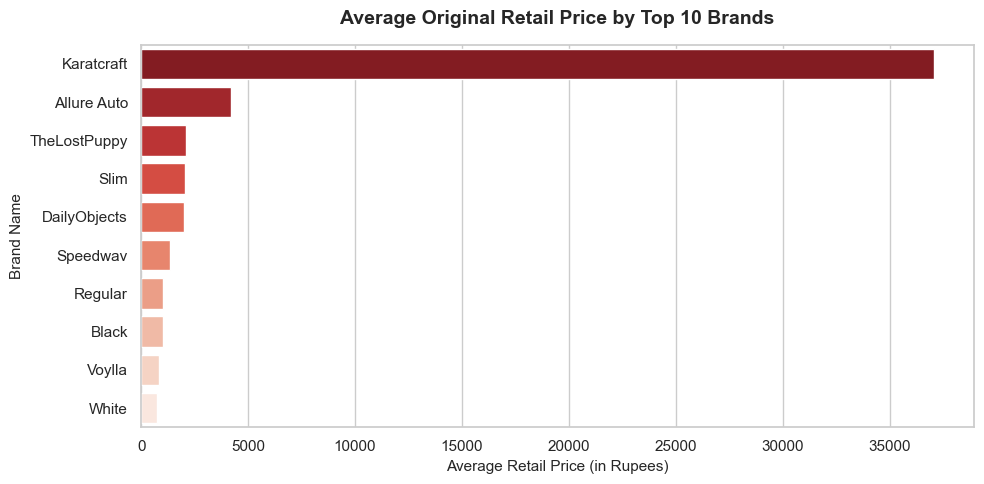

In [87]:
# avg price
brand_prices_sorted = df_top_brands.groupby('brand')['retail_price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='retail_price',
    y='brand',
    data=brand_prices_sorted,
    hue='brand',         
    legend=False,       
    palette="Reds_r"   
)

plt.title("Average Original Retail Price by Top 10 Brands", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Retail Price (in Rupees)", fontsize=11)
plt.ylabel("Brand Name", fontsize=11)

plt.tight_layout()
plt.show()

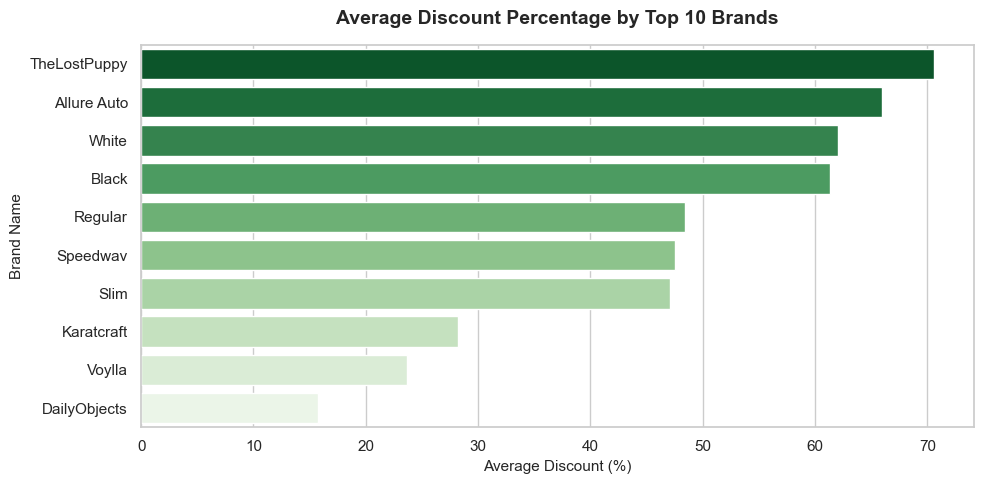

In [88]:
brand_discounts_sorted = df_top_brands.groupby('brand')['discount_percentage'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='discount_percentage',
    y='brand',
    data=brand_discounts_sorted,
    hue='brand',         
    legend=False,        
    palette="Greens_r"   
)

plt.title("Average Discount Percentage by Top 10 Brands", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Discount (%)", fontsize=11)
plt.ylabel("Brand Name", fontsize=11)

plt.tight_layout()
plt.show()

In [89]:
# Paste your folder path inside the quotes below
folder_path = r"C:\Users\heman\Downloads\flipkart_cleaned_data.xlsx"

# This saves the clean CSV right into that exact folder
df.to_csv(f"{"C:\Users\heman\Downloads\flipkart_cleaned_data.xlsx"}/flipkart_clean_final.csv", index=False, encoding='utf-8')

print("File successfully saved right next to your original sample file!")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (974333561.py, line 5)

In [ ]:
# Save the clean CSV directly into your Downloads folder
df.to_csv(r"C:\Users\heman\Downloads\flipkart_clean_final.csv", index=False, encoding='utf-8')

print("Success! File successfully saved to your Downloads folder.")

In [99]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,discount_amount,discount_percentage,primary_category
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,4.0,4.0,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",620.0,62.062062,Clothing
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,4.0,4.0,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati...",9511.0,29.576764,Furniture
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,4.0,4.0,AW,"{""product_specification""=>[{""key""=>""Ideal For""...",500.0,50.050050,Footwear
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,4.0,4.0,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",432.0,61.802575,Clothing
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,4.0,4.0,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",10.0,4.545455,Pet Supplies


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19922 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  19922 non-null  object 
 1   crawl_timestamp          19922 non-null  object 
 2   product_url              19922 non-null  object 
 3   product_name             19922 non-null  object 
 4   product_category_tree    19922 non-null  object 
 5   pid                      19922 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19919 non-null  object 
 9   is_FK_Advantage_product  19922 non-null  object 
 10  description              19920 non-null  object 
 11  product_rating           19922 non-null  float64
 12  overall_rating           19922 non-null  float64
 13  brand                    19922 non-null  object 
 14  product_specifications   19